In [1]:
from functions import *
import os
import matplotlib.pyplot as plt
import corner
import matplotlib.gridspec as gridspec
import h5py
import matplotlib
from mpl_toolkits.axes_grid.inset_locator import inset_axes

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: The mpl_toolkits.axes_grid module was deprecated in version 2.1. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist provies the same functionality instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


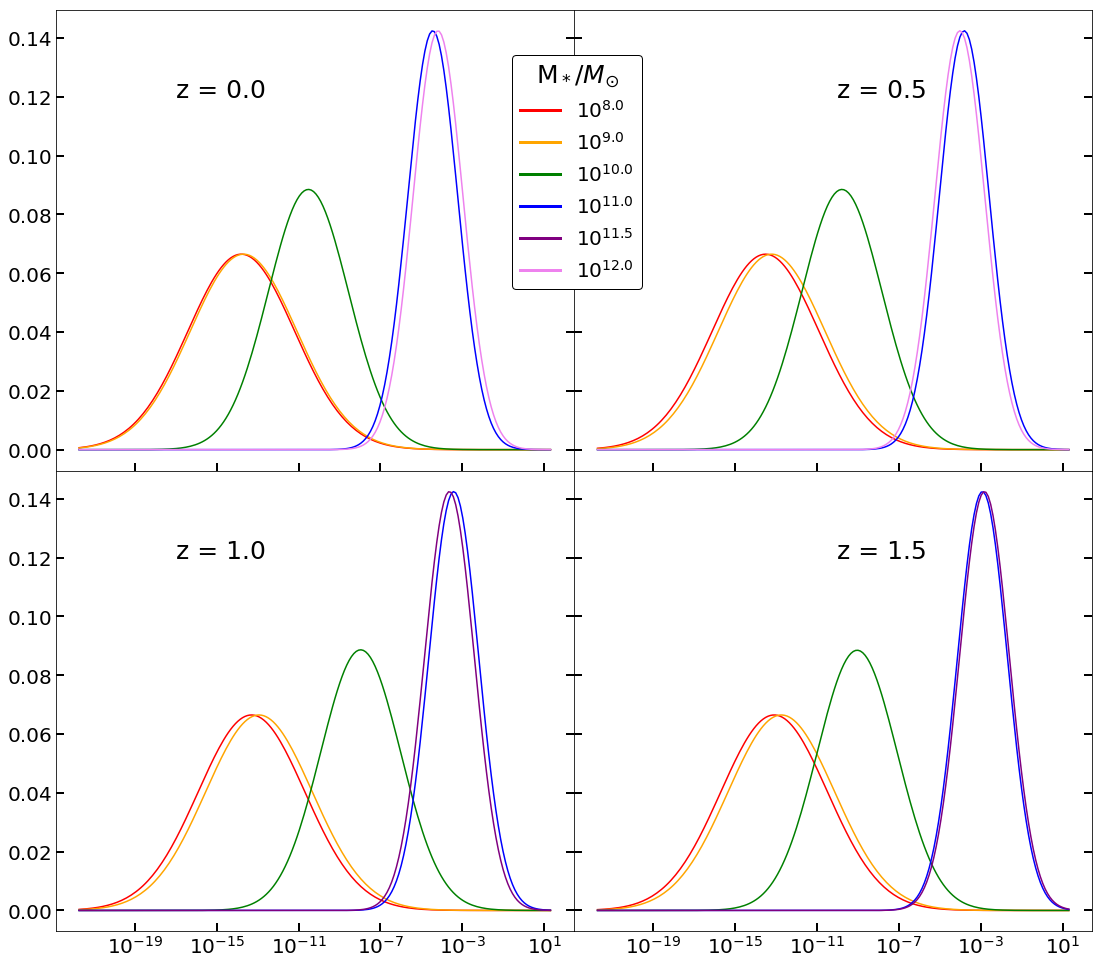

In [33]:
fig = plt.figure(figsize=(18,16))
zlist = [0.0, 0.5, 1.0, 1.5]
color = ['r','orange','green','blue','violet']
dlnMstar = 0.7
bins = 2000
dM = 0.3
siglnX = [6.0,2.8]
fs = 20
tw = 2
tl = 8
ls = 20
lw = 1.5

######### AXIS 1
ax1 = fig.add_axes([0.1, 0.5, 0.4, 0.4])

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[0], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(siglnX)

lnMdot = qlf.Mdot_sig[:,0]
sigs = qlf.Mdot_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )
    if mass < 11.5:
        ax1.plot(np.e**x, y, color=c, lw= lw, label=r'$10^{'+str(mass)+'}$')
    else:
        ax1.plot(np.e**x, y, color=c, lw= lw)
ax1.text(10e-18,.12,'z = '+str(zlist[0]), fontsize = fs+5) 
ax1.set_xscale('log')
ax1.axis([np.e**x[0],np.e**x[-1], 0, max(y)+0.01])
ax1.tick_params(direction='in', width = tw, length = tl, right = True, labelsize= ls)
plt.setp(ax1.get_xticklabels(), visible=False)


######### AXIS 3
ax3 = fig.add_axes([0.1, 0.1, 0.4, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[2], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(siglnX)

lnMdot = qlf.Mdot_sig[:,0]
sigs = qlf.Mdot_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )
    if mass == 11.5:
        ax3.plot(np.e**x, y, color='purple', lw= lw, label=r'$10^{'+str(mass)+'}$')
    else:
        ax3.plot(np.e**x, y, color=c, lw= lw)
ax3.text(10e-18,.12,'z = '+str(zlist[2]), fontsize = fs+5)  
ax3.tick_params(direction='in', width = tw, length = tl, right = True, labelsize= ls)


######### AXIS 2
ax2 = fig.add_axes([0.5, 0.5, 0.4, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[1], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(siglnX)

lnMdot = qlf.Mdot_sig[:,0]
sigs = qlf.Mdot_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )
    if mass == 12.0:
        ax2.plot(np.e**x, y, color=c, lw= lw, label=r'$10^{'+str(mass)+'}$')
    else:
        ax2.plot(np.e**x, y, color=c, lw= lw)
ax2.text(10e-11,.12,'z = '+str(zlist[1]), fontsize = fs+5)  
ax2.tick_params(direction='in', width = tw, length = tl, right = True, labelsize= ls)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)

######### AXIS 4
ax4 = fig.add_axes([0.5, 0.1, 0.4, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[3], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(siglnX)

lnMdot = qlf.Mdot_sig[:,0]
sigs = qlf.Mdot_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )
    if mass == 11.5:
        ax4.plot(np.e**x, y, color='purple', lw= lw)
    else:
        ax4.plot(np.e**x, y, color=c, lw= lw)
ax4.text(10e-11,.12,'z = '+str(zlist[3]), fontsize = fs+5)  
ax4.tick_params(direction='in', width = tw, length = tl, right = True, labelsize= ls)
plt.setp(ax4.get_yticklabels(), visible=False)


plt.tight_layout()
leg = fig.legend(fontsize = fs, loc = (.465,.7), facecolor='white', edgecolor='k', framealpha=1.0, title=r'M$_*/M_{\odot}$', )
for legobj in leg.legendHandles:
    legobj.set_linewidth(3.0)
plt.setp(leg.get_title(),fontsize=fs+5)
plt.savefig('poster-plots/distribution-both_forvarry_Mstar.pdf', transparent = True)

In [ ]:
plt.close('all')

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'BuGn'

f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
extent = f['extent'][:]
bins = f.attrs['bins']
f.close()

totpoints = 732

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((bins, bins))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
    grid2d = f['z='+str(z)+'/chi2_grid'][:]
    maxval = f['z='+str(z)+'/min-max'][:][1]
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()

    ax = fig.add_subplot(gs[i, j])
    maxl = []
    for n in grid2d:
        maxl.append(max(n))
    maxval = max(maxl)
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3,1,6])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = 0.5)
    if z == 1.0:
        cont1 = plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = 0.5)

    stack += np.e**(-grid2d/maxval) * (numob/totpoints)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack, cmap=contcmap, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()
plt.savefig('poster-plots/chi2_grid_obsfix.pdf')